

# Loan Default Probability 

The goal of this case study is to build a machine learning model to predict the probability that a loan will default.

## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)
    * [2.2. Load Dataset](#1.2)
* [3. Data Preparation and Feature Selection](#2)
    * [3.1. Preparing the predicted variable](#2.1)
    * [3.2. Feature Selection-Limit the Feature Space](#2.2)
        * [3.2.1.  Features elimination by significant missing values ](#2.2.1)
        * [3.2.2.  Features elimination based on the intutiveness](#2.2.2)
        * [3.2.3.  Features elimination based on the correlation](#2.2.3)
* [4. Feature Engineering and Exploratory Analysis](#3)
    * [4.1 Feature Analysis and Exploration](#3.1)
        * [4.1.1. Analysing the categorical features](#3.1.1)
        * [4.1.2  Analysing the continuous features ](#3.1.2)
    * [4.2.Encoding Categorical Data](#3.2)
    * [4.3.Sampling Data](#3.3)
* [5.Evaluate Algorithms and Models](#4)
    * [5.1. Train/Test Split](#4.1)
    * [5.2. Test Options and Evaluation Metrics](#4.2)
    * [5.3. Compare Models and Algorithms](#4.3)
* [6. Model Tuning and Grid Search](#5)
* [7. Finalize the Model](#6)
    * [7.1. Results on test dataset](#6.1)
    * [7.1. Variable Intuition/Feature Selection](#6.2)
    * [7.3. Save model for later use](#6.3)


<a id='0'></a>
# 1. Problem Definition

The problem is defined in the classification framework, where the predicted variable
is “Charge-Off ”. A charge-off is a debt that a creditor has given up trying to collect on
after you’ve missed payments for several months. The predicted variable takes value 1
in case of charge-off and 0 otherwise.

This case study aims to analyze data for loans through 2007-2017Q3 from Lending Club available on Kaggle. Dataset contains over 887 thousand observations and 150 variables among which one is describing the loan status. 

<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

In [1]:
!pip install scikeras



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Load libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Libraries for Deep Learning Models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

# Use SciKeras instead of deprecated keras.wrappers
from scikeras.wrappers import KerasClassifier

# Libraries for Saving the Model
from pickle import dump, load

<a id='1.2'></a>
## 2.2. Loading the Data

We load the data in this step.

#### <font color='red'>Note : Due to limit in the github for the data size, a sample of the data has been loaded in the jupyter notebook repository of this book. However, all the subsequent results in this jupyter notebook is with actual data (~1GB) under https://www.kaggle.com/mlfinancebook/lending-club-loans-data. You should load the full data in case you want to reproduce the results. </font> 

In [3]:
# load dataset
loans = pd.read_csv('LoansData_sample.csv')
#loans = pd.read_csv('LoansData.csv.gz', compression='gzip', low_memory=True) #Use this for the actual data

/var/folders/8z/n0hy_ppj36546yyyl4thlr580000gn/T/ipykernel_61585/1296985978.py:2: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  loans = pd.read_csv('LoansData_sample.csv')


In [4]:
dataset = loans

In [5]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
type(dataset)

pandas.DataFrame

<a id='2'></a>
## 3. Data Preparation and Feature Selection

<a id='2.1'></a>
## 3.1. Preparing the predicted variable


In [7]:
dataset.head(5)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,38098114,NaN,15000.0,15000.0,15000.0,60 months,12.39,336.64,C,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,1,36805548,NaN,10400.0,10400.0,10400.0,36 months,6.99,321.08,A,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,2,37842129,NaN,21425.0,21425.0,21425.0,60 months,15.59,516.36,D,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,3,37612354,NaN,12800.0,12800.0,12800.0,60 months,17.14,319.08,D,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,4,37662224,NaN,7650.0,7650.0,7650.0,36 months,13.66,260.20,C,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# We're going to try to predict the loan_status variable. What are the value counts for this variable
dataset['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid            69982
Charged Off           16156
Current               12726
Late (31-120 days)      730
In Grace Period         264
Late (16-30 days)       139
Default                   3
Name: count, dtype: int64

We're going to try to learn differences in the features between completed loans that have been fully paid or charged off. We won't consider loans that are current, don't meet the credit policy, defaulted, or have a missing status. So we only keep the loans with status "Fully Paid" or "Charged Off."

In [9]:
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])]

dataset['loan_status'].value_counts(dropna=False)

dataset['loan_status'].value_counts(normalize=True, dropna=False)

loan_status
Fully Paid     0.812441
Charged Off    0.187559
Name: proportion, dtype: float64

About 79% of the remaining loans have been fully paid and 21% have charged off, so we have a somewhat unbalanced classification problem.

In [10]:
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)
dataset['charged_off']

0        0
1        1
2        0
4        1
5        0
        ..
99994    0
99995    0
99996    0
99998    1
99999    0
Name: charged_off, Length: 86138, dtype: uint8

<a id='2.2'></a>
## 3.2. Feature Selection-Limit the Feature Space 

The full dataset has 150 features for each
loan. We’ll eliminate
features in following steps using three different approaches:
* Eliminate feature that have more than 30% missing values.
* Eliminate features that are unintuitive based on subjective judgement.
* Eliminate features with low correlation with the predicted variable

<a id='2.2.1'></a>
### 3.2.1.  Features elimination by significant missing values

First calculating the percentage of missing data for each feature:

In [11]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

total_cu_tl                            1.0
annual_inc_joint                       1.0
sec_app_mths_since_last_major_derog    1.0
sec_app_collections_12_mths_ex_med     1.0
sec_app_chargeoff_within_12_mths       1.0
open_rv_12m                            1.0
sec_app_num_rev_accts                  1.0
sec_app_open_act_il                    1.0
sec_app_revol_util                     1.0
sec_app_open_acc                       1.0
dtype: float64

In [12]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_ma

In [13]:
len(drop_list)

58

In [14]:
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(86138, 93)

<a id='2.2.2'></a>
### 3.2.2.  Features elimination based on the intutiveness

In order to filter the features further we check the description in the data dictionary and keep the features that are
intuitive on the basis of subjective judgement. 

We examine the LendingClub website and Data Dictionary to determine which features would have been available to potential investors. Here's the list of features we currently have, in alphabetical order:

In [15]:
print(sorted(dataset.columns))

['Unnamed: 0', 'acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_

The list that is kept is as follows: 

In [16]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',"bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]
# last_pymnt_amnt is deliberately excluded: it's a post-origination field (the borrower's
# most recent payment on an already-funded loan) that doesn't exist at approval time, so
# training on it leaks the outcome we're trying to predict.

len(keep_list)

39

In [17]:
drop_list = [col for col in dataset.columns if col not in keep_list]

dataset.drop(labels=drop_list, axis=1, inplace=True)

dataset.shape

(86138, 38)

<a id='2.2.3'></a>
### 3.2.3.  Features elimination based on the correlation

In [18]:
# Only include numeric columns
numeric_data = dataset.select_dtypes(include=[np.number])
correlation = numeric_data.corr()

# Now you can safely access correlation with 'charged_off'
correlation_chargeOff = abs(correlation['charged_off']).sort_values(ascending=False)
print(correlation_chargeOff)


charged_off              1.000000
int_rate                 0.282825
dti                      0.123108
fico_range_low           0.121892
fico_range_high          0.121891
acc_open_past_24mths     0.105989
bc_open_to_buy           0.080077
bc_util                  0.077744
avg_cur_bal              0.071977
num_actv_rev_tl          0.071185
revol_util               0.066188
loan_amnt                0.060818
funded_amnt              0.060818
mort_acc                 0.057858
annual_inc               0.050349
mo_sin_old_rev_tl_op     0.049426
mo_sin_rcnt_rev_tl_op    0.048839
open_acc                 0.039430
installment              0.032847
revol_bal                0.021714
pub_rec                  0.016023
pub_rec_bankruptcies     0.015815
total_acc                0.005804
id                       0.002221
Name: charged_off, dtype: float64


In [19]:
correlation_chargeOff.sort_values(ascending=False)

charged_off              1.000000
int_rate                 0.282825
dti                      0.123108
fico_range_low           0.121892
fico_range_high          0.121891
acc_open_past_24mths     0.105989
bc_open_to_buy           0.080077
bc_util                  0.077744
avg_cur_bal              0.071977
num_actv_rev_tl          0.071185
revol_util               0.066188
funded_amnt              0.060818
loan_amnt                0.060818
mort_acc                 0.057858
annual_inc               0.050349
mo_sin_old_rev_tl_op     0.049426
mo_sin_rcnt_rev_tl_op    0.048839
open_acc                 0.039430
installment              0.032847
revol_bal                0.021714
pub_rec                  0.016023
pub_rec_bankruptcies     0.015815
total_acc                0.005804
id                       0.002221
Name: charged_off, dtype: float64

In [20]:
drop_list_corr = sorted(list(correlation_chargeOff[correlation_chargeOff < 0.03].index))
print(drop_list_corr)

['id', 'pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'total_acc']


In [21]:
dataset.drop(labels=drop_list_corr, axis=1, inplace=True)
dataset.shape

(86138, 33)

<a id='3'></a>
# 4. Feature Engineering and Exploratory Analysis

In [22]:
#Descriptive Statistics
dataset.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,open_acc,revol_util,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off
count,86138.000000,86138.000000,86138.000000,86138.000000,8.613800e+04,86138.000000,86138.000000,86138.000000,86138.000000,86094.000000,86138.000000,86138.000000,85142.000000,85089.000000,86138.000000,86138.000000,86138.000000,86138.000000,86138.000000
mean,14106.526446,14106.526446,13.002360,430.737187,7.384311e+04,18.532747,692.462966,696.463024,11.746453,54.582777,4.594732,13066.638371,8942.506507,63.808959,183.524333,12.796896,1.748880,5.762358,0.187559
std,8391.139221,8391.139221,4.397419,251.653139,5.929352e+04,8.538247,29.731549,29.731848,5.433122,23.515901,3.070996,16232.739293,14100.186250,27.051347,93.266430,16.224586,2.091488,3.224598,0.390362
min,1000.000000,1000.000000,6.000000,30.420000,4.000000e+03,0.000000,660.000000,664.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,7800.000000,7800.000000,9.490000,248.480000,4.500000e+04,12.070000,670.000000,674.000000,8.000000,37.200000,2.000000,3010.000000,1087.000000,44.100000,118.000000,3.000000,0.000000,3.000000,0.000000
50%,12000.000000,12000.000000,12.990000,370.480000,6.247372e+04,17.950000,685.000000,689.000000,11.000000,54.900000,4.000000,6994.500000,3823.000000,67.700000,167.000000,8.000000,1.000000,5.000000,0.000000
75%,20000.000000,20000.000000,15.610000,568.005000,9.000000e+04,24.500000,705.000000,709.000000,14.000000,72.500000,6.000000,17905.000000,10588.000000,87.500000,232.000000,15.000000,3.000000,7.000000,0.000000
max,35000.000000,35000.000000,26.060000,1408.130000,7.500000e+06,39.990000,845.000000,850.000000,84.000000,180.300000,53.000000,447433.000000,249625.000000,255.200000,718.000000,372.000000,34.000000,38.000000,1.000000


<a id='3.1'></a>
## 4.1 Feature Analysis and Exploration

<a id='3.1.1'></a>
### 4.1.1. Analysing the categorical features 

In [23]:
dataset[['emp_title','title','zip_code']].describe()

,emp_title,title,zip_code
count,81416,86138,86138
unique,32987,20,846
top,Teacher,Debt consolidation,750xx
freq,1576,52990,954


In [24]:
#Ids are all unique and there are too many job titles and titles and zipcode, 
#these column is dropped The ID is not useful for modeling.
dataset.drop(['emp_title','title','zip_code'], axis=1, inplace=True)

#### Feature- Term

In [25]:
#Data Dictionary: "The number of payments on the loan. Values are in months and can be either 36 or 60.". 
#The 60 Months loans are more likelely to charge off
#Convert term to integers
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))

In [26]:
dataset.groupby('term')['charged_off'].value_counts(normalize=True).loc[:,1]

term
36    0.141526
60    0.354356
Name: proportion, dtype: float64

Loans with five-year periods are more than twice as likely to charge-off as loans with three-year periods.

#### Feature- Employement Length

In [27]:
print(dataset['emp_length'].unique())

<ArrowStringArray>
['10+ years',   '8 years',   '6 years',  '< 1 year',   '2 years',   '9 years',
   '7 years',   '3 years',    '1 year',         nan,   '4 years',   '5 years']
Length: 12, dtype: str


In [28]:
dataset["emp_length"] = (
    dataset["emp_length"]
    .replace({"< 1 year": "0", "10+ years": "10"})
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

<Axes: xlabel='emp_length'>

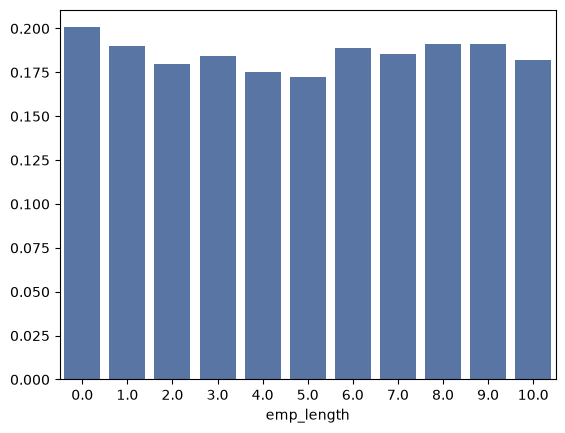

In [29]:
charge_off_rates = dataset.groupby('emp_length')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

 Loan status does not appear to vary much with employment length on average, hence it is dropped

In [30]:
dataset.drop(['emp_length'], axis=1, inplace=True)

#### Feature : Subgrade

<Axes: xlabel='sub_grade'>

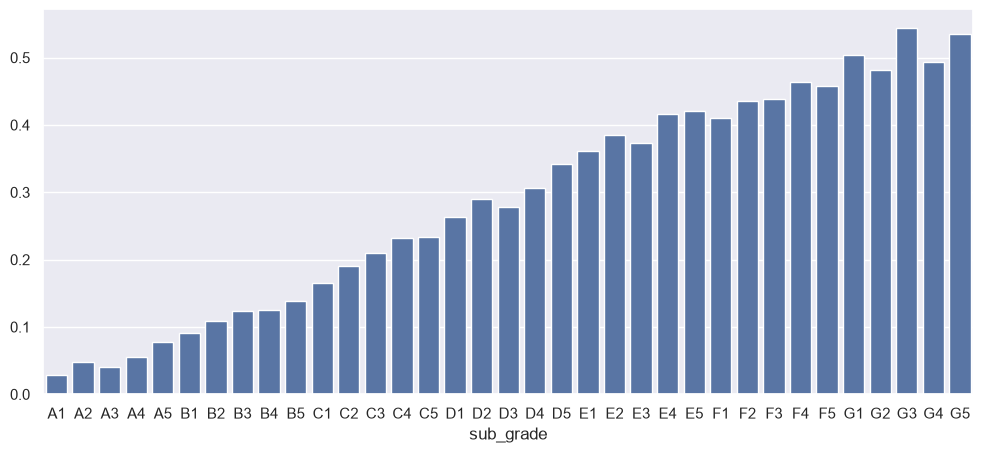

In [31]:
charge_off_rates = dataset.groupby('sub_grade')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.set(rc={'figure.figsize':(12,5)})
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)


There's a clear trend of higher probability of charge-off as the subgrade worsens.

In [32]:
dataset['earliest_cr_line'] = dataset['earliest_cr_line'].apply(lambda s: int(s[-4:]))

<a id='3.1.2'></a>
### 4.1.2. Analysing the continuous features 

#### Feature : Annual Income

In [33]:
dataset[['annual_inc']].describe()

,annual_inc
count,8.613800e+04
mean,7.384311e+04
std,5.929352e+04
min,4.000000e+03
25%,4.500000e+04
50%,6.247372e+04
75%,9.000000e+04
max,7.500000e+06


Annual income ranges from 0  to  9,550,000, with a median of $65,000. 
Because of the large range of incomes, we should take a log transform of the annual income variable.

In [34]:
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x: np.log10(x+1))
dataset.drop('annual_inc', axis=1, inplace=True)

#### FICO Scores

In [35]:
dataset[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


Given that the correlation between fico low and high is 1 it is preferred to keep only one feature which is average of FICO Scores

In [36]:
dataset['fico_score'] = 0.5*dataset['fico_range_low'] + 0.5*dataset['fico_range_high']

dataset.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

In [37]:
dataset['charged_off'].value_counts()

charged_off
0    69982
1    16156
Name: count, dtype: int64

<a id='3.2'></a>
## 4.2. Encoding Categorical Data

In [38]:
from sklearn.preprocessing import LabelEncoder

In [39]:
# Categorical boolean mask
# NOTE: dtypes==object misses columns stored with pandas' newer 'string'/'str' dtype,
# which caused categorical_cols to come out empty and left text columns (grade, purpose, etc.)
# unencoded -> "could not convert string to float" errors during K-fold cross validation.
# select_dtypes catches object, pandas StringDtype, and category dtypes all at once.
categorical_cols = dataset.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

In [40]:
categorical_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [41]:
# Fit one LabelEncoder per categorical column and keep them in `encoders` so they
# can be persisted later. A single shared encoder would only retain the fit for
# the last column processed, which breaks reuse/persistence at inference time.
encoders = {}
if categorical_cols:
    for col in categorical_cols:
        col_encoder = LabelEncoder()
        dataset[col] = col_encoder.fit_transform(dataset[col].astype(str))
        encoders[col] = col_encoder
dataset[categorical_cols].head(10)

,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,2,10,3,1,2,40,1,0
1,0,2,1,0,1,4,1,0
2,3,15,3,1,1,21,1,0
4,2,12,3,1,2,3,0,0
5,2,12,3,1,2,26,0,0
6,1,9,1,1,3,20,0,0
7,1,8,2,2,2,40,1,0
8,2,13,3,1,1,42,0,0
9,1,8,3,0,2,18,0,0
10,1,9,3,2,2,19,0,0


In [42]:
dataset.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,15000.0,15000.0,60,12.39,336.64,2,10,3,1,2,...,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0,4.892100,752.0
1,10400.0,10400.0,36,6.99,321.08,0,2,1,0,1,...,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,1,4.763435,712.0
2,21425.0,21425.0,60,15.59,516.36,3,15,3,1,1,...,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0,4.804827,687.0
4,7650.0,7650.0,36,13.66,260.20,2,12,3,1,2,...,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,1,4.698979,687.0
5,9600.0,9600.0,36,13.66,326.53,2,12,3,1,2,...,3214.0,6494.0,69.2,265.0,23.0,0.0,7.0,0,4.838855,682.0


In [43]:
dataset.shape

(86138, 28)

<a id='3.4'></a>
## 4.3. Sampling Data

In [44]:
loanstatus_0 = dataset[dataset["charged_off"]==0]
loanstatus_1 = dataset[dataset["charged_off"]==1]
subset_of_loanstatus_0 = loanstatus_0.sample(n=5500)
subset_of_loanstatus_1 = loanstatus_1.sample(n=5500)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1).reset_index(drop=True)
print("Current shape of dataset :",dataset.shape)
dataset.head()

Current shape of dataset : (11000, 28)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,18400.0,18400.0,60,14.49,432.83,2,13,1,0,2,...,15913.0,3691.0,85.2,257.0,20.0,1.0,5.0,1,4.903095,662.0
1,10000.0,10000.0,60,15.99,243.13,3,16,1,1,2,...,16560.0,2552.0,64.1,66.0,4.0,1.0,4.0,1,5.000004,692.0
2,12000.0,12000.0,36,13.35,406.36,2,11,1,2,1,...,8685.0,9427.0,67.4,124.0,0.0,1.0,10.0,0,4.681250,677.0
3,20000.0,20000.0,60,10.49,429.78,1,7,1,1,2,...,21583.0,10761.0,65.7,243.0,8.0,8.0,6.0,0,4.903095,702.0
4,10000.0,10000.0,60,12.99,227.48,2,10,2,1,1,...,2467.0,3483.0,58.5,196.0,17.0,0.0,3.0,0,4.556315,682.0


<a id='4'></a>
# 5. Evaluate Algorithms and Models

<a id='4.1'></a>
## 5.1. Train Test Split

In [45]:
# split out validation dataset for the end
Y= dataset["charged_off"]
X = dataset.loc[:, dataset.columns != 'charged_off']
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

## 5.1b. Dimensionality Reduction (PCA)

Impute, scale, and PCA-transform using statistics from the **training split only**, then apply those same fitted transforms to the validation split. Fitting on the full dataset before the split (as an earlier version of this notebook did) leaks validation-set statistics — feature means used for imputation, the scaler's mean/variance, and the PCA components themselves — into the transform, which inflates validation metrics.

In [46]:
from sklearn.decomposition import PCA

# Impute with the training-split mean only, then fit scaling/PCA on the training
# split and apply the same fitted transforms to validation.
train_means = X_train.mean(numeric_only=True)
X_train = X_train.fillna(train_means)
X_validation = X_validation.fillna(train_means)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

# Keep enough components to explain 95% of the variance
pca = PCA(n_components=0.95, random_state=7)
X_train_pca = pca.fit_transform(X_train_scaled)
X_validation_pca = pca.transform(X_validation_scaled)

print(f"Reduced from {X_train.shape[1]} features to {pca.n_components_} "
      f"principal components (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

pca_cols = [f'pc_{i+1}' for i in range(X_train_pca.shape[1])]
X_train = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
X_validation = pd.DataFrame(X_validation_pca, columns=pca_cols, index=X_validation.index)

Reduced from 27 features to 17 principal components (explained variance: 0.951)


In [47]:
# dataset_temp2=dataset_temp.dropna(axis=0)
# Y_total= dataset_temp2["charged_off"]
# X_total = dataset_temp2.loc[:, dataset.columns != 'charged_off']
# X_dummy, X_validation, Y_dummy, Y_validation = train_test_split(X_total, Y_total, test_size=validation_size)

In [48]:
dataset['charged_off'].value_counts()

charged_off
1    5500
0    5500
Name: count, dtype: int64

<a id='4.2'></a>
## 5.2. Test Options and Evaluation Metrics


In [49]:
# test options for classification
num_folds = 10
seed = 7

scoring = 'roc_auc'

<a id='4.3'></a>
## 5.3. Compare Models and Algorithms

### Classification Models

In [50]:
# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#Neural Network
models.append(('NN', MLPClassifier()))
#Ensable Models
# Boosting methods
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
# Bagging methods
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))

### K-folds cross validation

In [51]:
print(X_train.select_dtypes(include=["object", "string"]).columns)

Index([], dtype='str')


In [52]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.733909 (0.013632)
LDA: 0.734132 (0.013621)


KNN: 0.662741 (0.010051)


CART: 0.580827 (0.011666)
NB: 0.715246 (0.016578)


NN: 0.702183 (0.014800)


AB: 0.719966 (0.016061)


GBM: 0.727190 (0.012164)


RF: 0.716844 (0.009110)


ET: 0.722008 (0.013736)


### Algorithm comparison

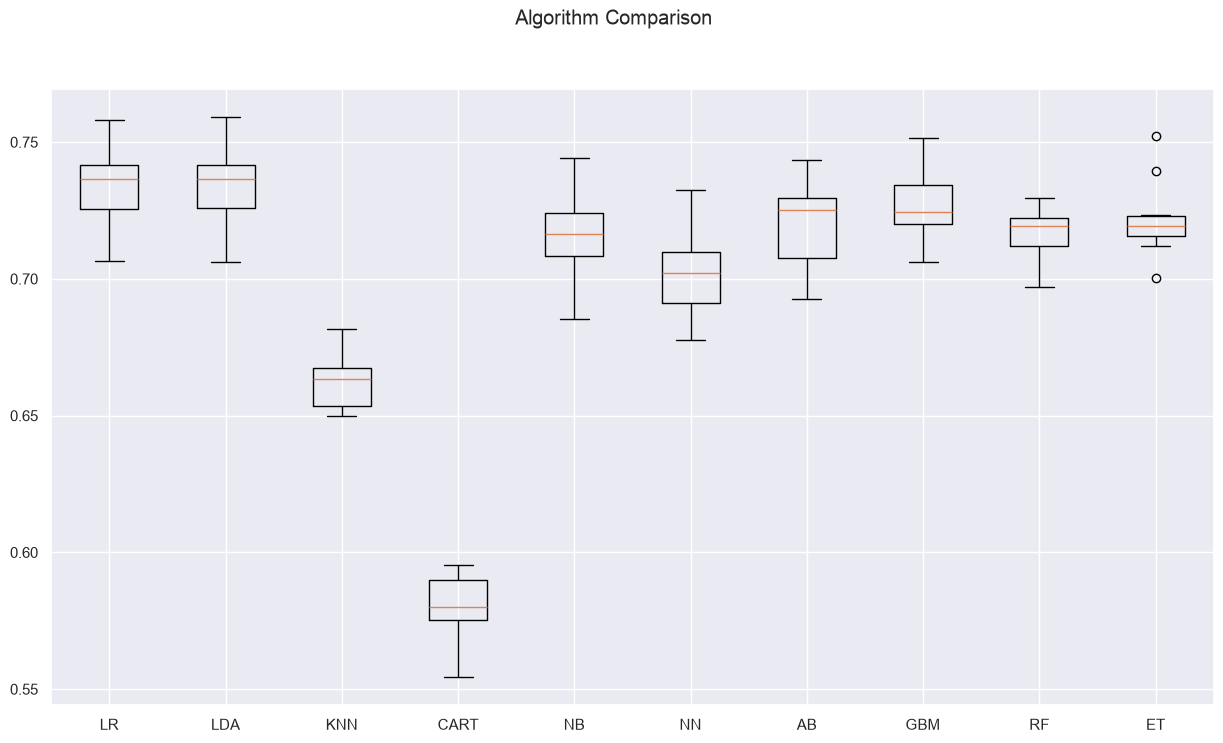

In [53]:
# compare algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()

<a id='5'></a>
# 6. Model Tuning and Grid Search

Logistic Regression and Linear Discriminant Analysis are statistically tied in the 10-fold cross-validation comparison above (ROC AUC ≈ 0.734 for both, well within one standard deviation of each other, ahead of the tree ensembles, neural network, and KNN/CART/NB). Logistic Regression is picked and Grid Search is performed on it in this step. (Note: an earlier version of this notebook fit scaling/PCA on the full dataset before the train/validation split and kept a post-origination field, `last_pymnt_amnt`, as a predictor — both leaked information and inflated this comparison's scores to ROC AUC ≈ 0.91. Both leaks are now fixed.)

In [54]:
# Grid Search: Logistic Regression Tuning
'''
C : float (default=1.0)
    Inverse of regularization strength; must be a positive float.
    Smaller values specify stronger regularization.
penalty : {'l1', 'l2'}
    Norm used in the penalization. The 'liblinear' solver supports both.
'''
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
penalty = ['l1', 'l2']
param_grid = dict(C=C_values, penalty=penalty)
model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed)
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

#Print Results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
ranks = grid_result.cv_results_['rank_test_score']
for mean, stdev, param, rank in zip(means, stds, params, ranks):
    print("#%d %f (%f) with: %r" % (rank, mean, stdev, param))

Best: 0.734016 using {'C': 0.01, 'penalty': 'l2'}
#12 0.706360 (0.017665) with: {'C': 0.001, 'penalty': 'l1'}
#10 0.733342 (0.013896) with: {'C': 0.001, 'penalty': 'l2'}
#11 0.729552 (0.014726) with: {'C': 0.01, 'penalty': 'l1'}
#1 0.734016 (0.013740) with: {'C': 0.01, 'penalty': 'l2'}
#9 0.733729 (0.013618) with: {'C': 0.1, 'penalty': 'l1'}
#2 0.733927 (0.013657) with: {'C': 0.1, 'penalty': 'l2'}
#3 0.733904 (0.013650) with: {'C': 1, 'penalty': 'l1'}
#7 0.733901 (0.013637) with: {'C': 1, 'penalty': 'l2'}
#8 0.733897 (0.013637) with: {'C': 10, 'penalty': 'l1'}
#5 0.733903 (0.013639) with: {'C': 10, 'penalty': 'l2'}
#6 0.733902 (0.013638) with: {'C': 100, 'penalty': 'l1'}
#4 0.733904 (0.013637) with: {'C': 100, 'penalty': 'l2'}


<a id='6'></a>
# 7. Finalise the Model

Looking at the details above, Logistic Regression is essentially tied with LDA for the highest cross-validated ROC AUC and is selected as the final model.

Finalize the model with the best parameters found during the tuning step.

<a id='6.1'></a>
## 7.1. Results on the Test Dataset

In [55]:
# prepare model
model = LogisticRegression(**grid_result.best_params_, solver='liblinear', max_iter=1000, random_state=seed)
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-

In [56]:
# estimate accuracy on validation set
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.6745454545454546
[[749 349]
 [367 735]]
              precision    recall  f1-score   support

           0       0.67      0.68      0.68      1098
           1       0.68      0.67      0.67      1102

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.67      2200
weighted avg       0.67      0.67      0.67      2200



<Axes: xlabel='Predicted', ylabel='Actual'>

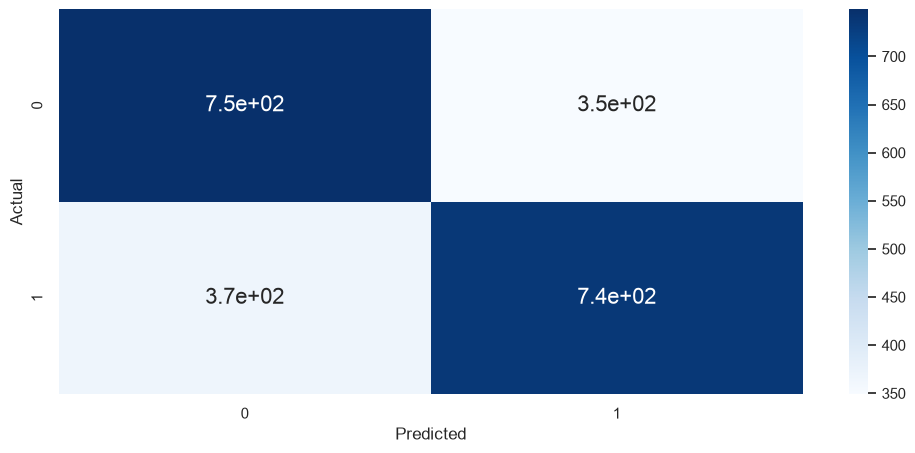

In [57]:
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 16})# font sizes

<a id='6.2'></a>
## 7.2. Variable Intuition/Feature Importance
Logistic Regression is a linear model, so instead of `feature_importances_` (a tree-based attribute) we look at its coefficients.
Let us look into the feature coefficients of the Logistic Regression model — larger absolute magnitude means a bigger influence on the charge-off prediction.

[ 0.13779653  0.40611921  0.13727062 -0.04445956 -0.04965051  0.14239199
  0.0935759  -0.00603293 -0.01680664 -0.02975213 -0.04891538  0.0416711
  0.04469966  0.09228941 -0.16894751  0.07203814 -0.12368267]


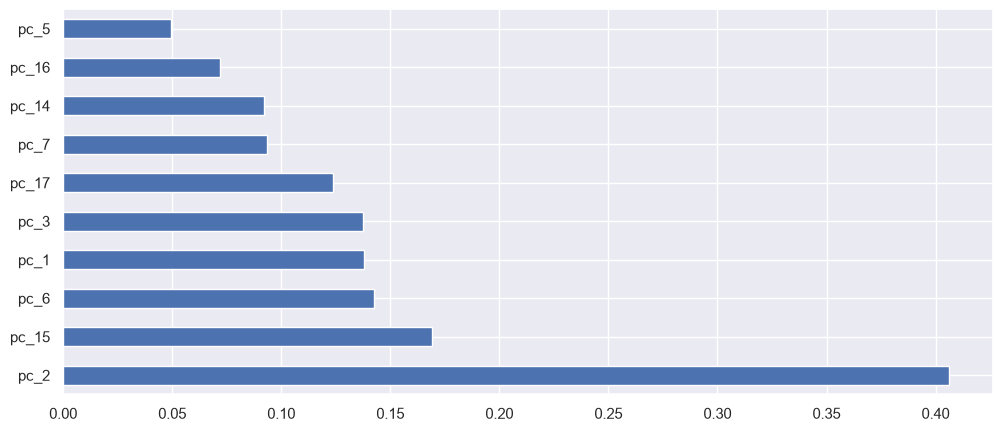

In [58]:
print(model.coef_[0]) #use inbuilt coef_ attribute of linear classifiers
#plot graph of feature coefficients (by absolute magnitude) for better visualization
feat_importances = pd.Series(np.abs(model.coef_[0]), index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
pyplot.show()

<a id='6.3'></a>
## 7.3. Save Model for Later Use

Persist the fitted model along with everything needed to reproduce its preprocessing at inference time: the per-column `LabelEncoder`s, the `StandardScaler`, and the `PCA` transform.

In [59]:
import joblib

joblib.dump(model, 'best_model.joblib')
joblib.dump(encoders, 'label_encoders.joblib')
joblib.dump(scaler, 'pca_scaler.joblib')
joblib.dump(pca, 'pca_transform.joblib')

print("Saved: best_model.joblib, label_encoders.joblib, pca_scaler.joblib, pca_transform.joblib")

Saved: best_model.joblib, label_encoders.joblib, pca_scaler.joblib, pca_transform.joblib


__Conclusion__:

We showed that data preparation is one of the most important steps. We addressed
that by performing feature elimination by using different techniques such as subjec‐
tive judgement, correlation, visualization and the data quality of the feature.
We illustrated that there can be different ways of handling and analyzing the categorical data and converting categorical data into model usable format.

Finally, we analyzed the feature importance and found that results of the case study
are quite intuitive.
